Machine Learning Momentum Trading Strategy

This notebook extends the trading-strategy framework in **Beaudan & He (2019), _Applying Machine Learning to Trading Strategies: Using Logistic Regression to Build Momentum-based Trading Strategies_**.

The paper recasts time-series dual momentum as a binary classification problem. Each day, the model predicts whether the index will earn at least a target annualized return over a short future horizon. If the model predicts success, the strategy is invested; otherwise, it moves to cash for the long-only version or goes short for the long-short version.

This notebook uses **recent Yahoo Finance data** through `yfinance`, so results will not exactly match the paper's Bloomberg sample from 1927 to 2018. The goal is methodological replication and practical experimentation.

> Educational/research use only. This is not financial advice, and transaction costs, taxes, bid-ask spreads, slippage, borrowing costs, and data-quality issues can materially change live results.

## Paper Design Being Replicated

Core design choices:

- Asset: S&P 500 index proxy, default ticker `^GSPC`.
- Features: historical momentum and drawdown metrics computed from adjusted close prices.
- Momentum windows: 30, 60, 90, 120, 180, 270, 300, 360 trading days.
- Drawdown windows: 15, 60, 90, 120 trading days.
- Target: future annualized return over horizon `H`; default `H = 3` trading days.
- Label: 1 if future annualized return ≥ `delta`; default `delta = 5%`.
- Model: logistic regression with polynomial features; default cubic degree 3 and L2 regularization.
- Train/test: walk-forward, using a rolling training window equal to 40% of the available cleaned sample.
- Rebalancing: daily prediction and daily strategy allocation.

The original paper also implements an autonomous retraining trigger using convergence of the test-set cost function. This notebook includes both a **fixed retraining interval** approximation and an **optional adaptive retraining skeleton** that you can extend.

## 1. Install and Import Libraries

In [1]:
# Uncomment if running in a fresh environment.
!pip install yfinance pandas numpy scikit-learn matplotlib scipy openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

RESULTS_DIR = Path("results")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
for p in [RESULTS_DIR, FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

## 2. Configuration

In [3]:
@dataclass
class StrategyConfig:
    ticker: str = "^GSPC"          # S&P 500 index from Yahoo Finance
    start: str = "1990-01-01"      # yfinance has reliable GSPC data from 1950s onward; use recent sample by default
    end: Optional[str] = None       # None = latest available
    momentum_windows: Tuple[int, ...] = (30, 60, 90, 120, 180, 270, 300, 360)
    drawdown_windows: Tuple[int, ...] = (15, 60, 90, 120)
    horizon: int = 3                # H: future prediction horizon in trading days
    delta: float = 0.05             # annualized profitability threshold
    annual_days: int = 252
    train_fraction: float = 0.40
    retrain_interval: int = 756     # about 3 trading years; change to 1900 to mimic paper's average retraining frequency
    polynomial_degree: int = 3
    regularization_C: float = 1.0   # sklearn C is inverse regularization strength; C=1 is close to lambda=1 conventionally
    long_short: bool = False        # False = long/cash, True = long/short
    rf_rate: float = 0.01           # paper uses 1% annual risk-free rate for Sharpe
    initial_capital: float = 1_000_000

cfg = StrategyConfig()
cfg

StrategyConfig(ticker='^GSPC', start='1990-01-01', end=None, momentum_windows=(30, 60, 90, 120, 180, 270, 300, 360), drawdown_windows=(15, 60, 90, 120), horizon=3, delta=0.05, annual_days=252, train_fraction=0.4, retrain_interval=756, polynomial_degree=3, regularization_C=1.0, long_short=False, rf_rate=0.01, initial_capital=1000000)

## 3. Download Market Data from Yahoo Finance

In [4]:
def download_price_data(ticker: str, start: str, end: Optional[str] = None) -> pd.DataFrame:
    data = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if data.empty:
        raise ValueError(f"No data returned for {ticker}. Try a different ticker or date range.")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    price_col = "Adj Close" if "Adj Close" in data.columns else "Close"
    out = data[[price_col]].rename(columns={price_col: "price"}).dropna()
    out.index = pd.to_datetime(out.index)
    return out

prices = download_price_data(cfg.ticker, cfg.start, cfg.end)
print(prices.head())
print(prices.tail())
print(f"Rows: {len(prices):,}, Start: {prices.index.min().date()}, End: {prices.index.max().date()}")

Price            price
Date                  
1990-01-02  359.690002
1990-01-03  358.760010
1990-01-04  355.670013
1990-01-05  352.200012
1990-01-08  353.790009
Price             price
Date                   
2026-04-20  7109.140137
2026-04-21  7064.009766
2026-04-22  7137.899902
2026-04-23  7108.399902
2026-04-24  7165.080078
Rows: 9,145, Start: 1990-01-02, End: 2026-04-24


## 4. Feature Engineering: Momentum, Drawdown, and Target Labels

In [5]:
def add_momentum_features(df: pd.DataFrame, windows: Tuple[int, ...]) -> pd.DataFrame:
    out = df.copy()
    for w in windows:
        out[f"mom_{w}"] = out["price"].pct_change(w)
    return out


def rolling_drawdown(series: pd.Series, window: int) -> pd.Series:
    rolling_max = series.rolling(window=window, min_periods=window).max()
    return series / rolling_max - 1.0


def add_drawdown_features(df: pd.DataFrame, windows: Tuple[int, ...]) -> pd.DataFrame:
    out = df.copy()
    for w in windows:
        out[f"dd_{w}"] = rolling_drawdown(out["price"], w)
    return out


def add_target(df: pd.DataFrame, horizon: int, delta: float, annual_days: int) -> pd.DataFrame:
    out = df.copy()
    future_price = out["price"].shift(-horizon)
    # Annualized future profitability as in the paper: (P_{t+H}/P_t)^(252/H) - 1
    out["future_ann_return"] = (future_price / out["price"]) ** (annual_days / horizon) - 1
    out["target"] = (out["future_ann_return"] >= delta).astype(int)
    return out


def make_modeling_frame(prices: pd.DataFrame, cfg: StrategyConfig) -> Tuple[pd.DataFrame, List[str]]:
    df = prices.copy()
    df["asset_ret"] = df["price"].pct_change()
    df = add_momentum_features(df, cfg.momentum_windows)
    df = add_drawdown_features(df, cfg.drawdown_windows)
    df = add_target(df, cfg.horizon, cfg.delta, cfg.annual_days)
    feature_cols = [c for c in df.columns if c.startswith("mom_") or c.startswith("dd_")]
    df = df.dropna().copy()
    return df, feature_cols

df, feature_cols = make_modeling_frame(prices, cfg)
print("Feature columns:", feature_cols)
print(df[["price", "asset_ret", "future_ann_return", "target"] + feature_cols].head())
print(f"Clean rows: {len(df):,}")
print("Target class balance:")
print(df["target"].value_counts(normalize=True).rename("share"))

Feature columns: ['mom_30', 'mom_60', 'mom_90', 'mom_120', 'mom_180', 'mom_270', 'mom_300', 'mom_360', 'dd_15', 'dd_60', 'dd_90', 'dd_120']
Price            price  asset_ret  future_ann_return  target    mom_30  \
Date                                                                     
1991-06-05  385.089996  -0.006834          -0.761739       0  0.008723   
1991-06-06  383.630005  -0.003791          -0.432680       0  0.002273   
1991-06-07  379.429993  -0.010948          -0.460825       0  0.000475   
1991-06-10  378.570007  -0.002267          -0.188470       0 -0.001187   
1991-06-11  381.049988   0.006551           0.313783       1  0.019777   

Price         mom_60    mom_90   mom_120   mom_180   mom_270   mom_300  \
Date                                                                     
1991-06-05  0.032524  0.145862  0.166268  0.208694  0.120034  0.125994   
1991-06-06  0.036754  0.141654  0.164845  0.211718  0.089858  0.125708   
1991-06-07  0.012975  0.129794  0.160975  0.2

## 5. Exploratory Plots

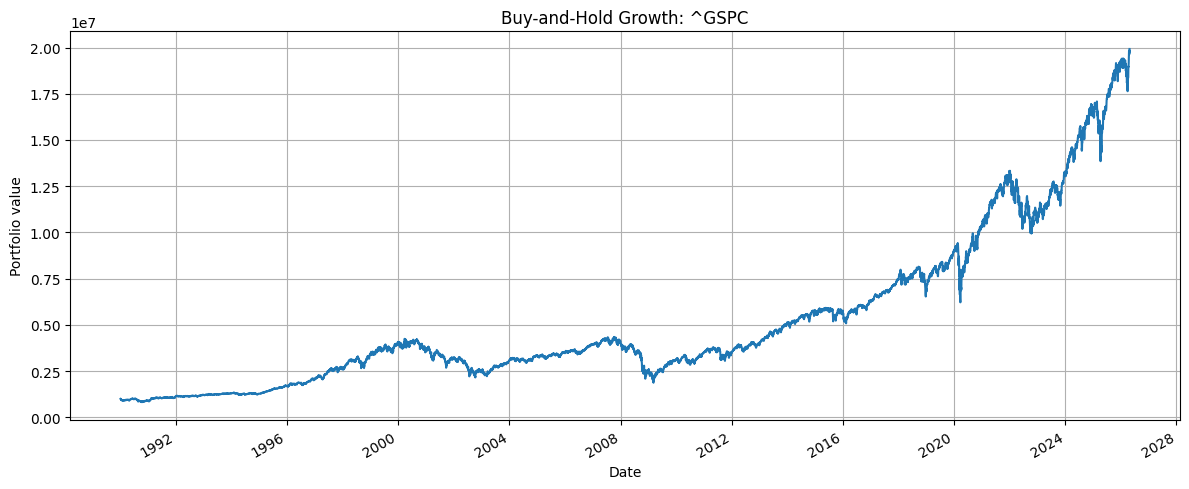

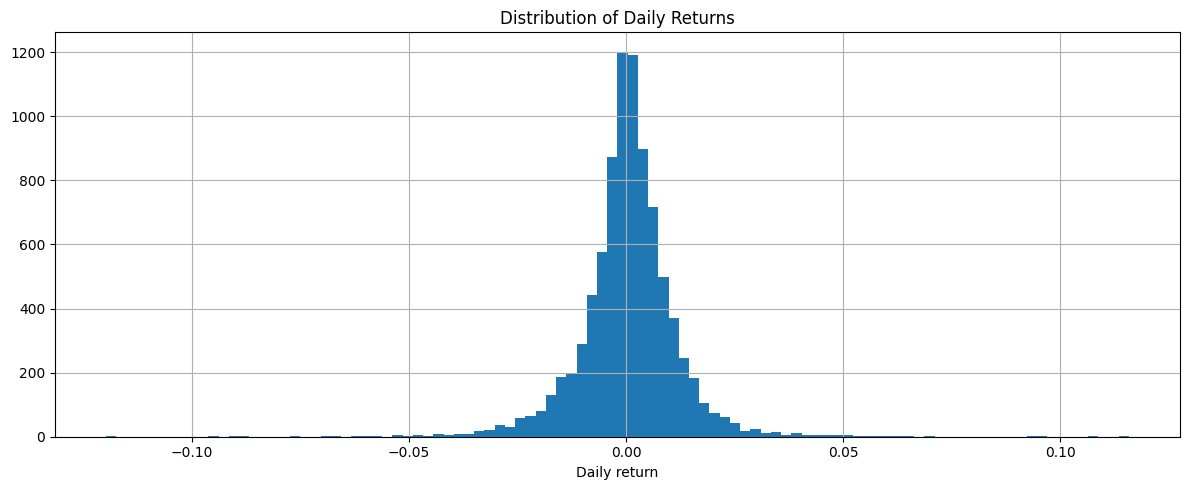

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
(prices["price"] / prices["price"].iloc[0] * cfg.initial_capital).plot(ax=ax)
ax.set_title(f"Buy-and-Hold Growth: {cfg.ticker}")
ax.set_ylabel("Portfolio value")
fig.tight_layout()
fig.savefig(FIG_DIR / "buy_hold_growth.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
df["asset_ret"].hist(bins=100, ax=ax)
ax.set_title("Distribution of Daily Returns")
ax.set_xlabel("Daily return")
fig.tight_layout()
fig.savefig(FIG_DIR / "daily_return_distribution.png", dpi=150)
plt.show()

## 6. Performance Metrics

In [7]:
def drawdown(equity: pd.Series) -> pd.Series:
    return equity / equity.cummax() - 1.0


def annualized_return(equity: pd.Series, annual_days: int = 252) -> float:
    equity = equity.dropna()
    if len(equity) < 2:
        return np.nan
    years = len(equity) / annual_days
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1


def annualized_volatility(returns: pd.Series, annual_days: int = 252) -> float:
    return returns.dropna().std() * np.sqrt(annual_days)


def sharpe_ratio(returns: pd.Series, rf_rate: float = 0.01, annual_days: int = 252) -> float:
    ann_ret = returns.dropna().mean() * annual_days
    ann_vol = annualized_volatility(returns, annual_days)
    if ann_vol == 0 or np.isnan(ann_vol):
        return np.nan
    return (ann_ret - rf_rate) / ann_vol


def sortino_ratio(returns: pd.Series, mar: float = 0.01, annual_days: int = 252) -> float:
    daily_mar = mar / annual_days
    downside = returns[returns < daily_mar] - daily_mar
    downside_dev = downside.std() * np.sqrt(annual_days)
    ann_ret = returns.mean() * annual_days
    if downside_dev == 0 or np.isnan(downside_dev):
        return np.nan
    return (ann_ret - mar) / downside_dev


def performance_summary(returns: pd.Series, equity: pd.Series, name: str, cfg: StrategyConfig) -> Dict[str, float]:
    dd = drawdown(equity)
    return {
        "Strategy": name,
        "Annual Return": annualized_return(equity, cfg.annual_days),
        "Sharpe Ratio": sharpe_ratio(returns, cfg.rf_rate, cfg.annual_days),
        "Sortino Ratio": sortino_ratio(returns, cfg.rf_rate, cfg.annual_days),
        "Volatility": annualized_volatility(returns, cfg.annual_days),
        "Max Drawdown": dd.min(),
        "Average Daily Drawdown": dd.mean(),
        "Final Equity": equity.iloc[-1],
    }

## 7. Classic Dual-Momentum Baseline

In [8]:
def classic_dual_momentum(df: pd.DataFrame, lookback: int = 252, skip: int = 21, threshold: float = 0.05,
                          rebalance_freq: int = 21, long_short: bool = False) -> pd.DataFrame:
    out = df.copy()
    # 12-month momentum skipping most recent 1 month: price[t-skip] / price[t-lookback-skip] - 1
    mom = out["price"].shift(skip) / out["price"].shift(lookback + skip) - 1
    annualized_mom = (1 + mom) ** (252 / lookback) - 1
    raw_signal = (annualized_mom > threshold).astype(float)
    if long_short:
        raw_signal = raw_signal.replace(0.0, -1.0)
    else:
        raw_signal = raw_signal.replace(0.0, 0.0)

    # Rebalance every rebalance_freq days and carry signal forward.
    signal = pd.Series(index=out.index, dtype=float)
    signal.iloc[::rebalance_freq] = raw_signal.iloc[::rebalance_freq]
    signal = signal.ffill().fillna(0.0)
    out["classic_signal"] = signal
    out["classic_ret"] = out["classic_signal"].shift(1).fillna(0.0) * out["asset_ret"].fillna(0.0)
    out["classic_equity"] = cfg.initial_capital * (1 + out["classic_ret"]).cumprod()
    return out

classic = classic_dual_momentum(df, lookback=252, skip=21, threshold=cfg.delta, rebalance_freq=21, long_short=cfg.long_short)
classic[["classic_signal", "classic_ret", "classic_equity"]].tail()

Price,classic_signal,classic_ret,classic_equity
Date,,,
2026-04-15,1.0,0.007976,1.158498e+07
2026-04-16,1.0,0.002610,1.161521e+07
2026-04-17,1.0,0.012040,1.175507e+07
2026-04-20,1.0,-0.002374,1.172716e+07
2026-04-21,1.0,-0.006348,1.165271e+07


## 8. Logistic Regression Pipeline

In [9]:
def make_logistic_pipeline(cfg: StrategyConfig) -> Pipeline:
    # MinMaxScaler(-1, 1) approximates the paper's normalization to [-1, +1].
    return Pipeline(steps=[
        ("scale", MinMaxScaler(feature_range=(-1, 1))),
        ("poly", PolynomialFeatures(degree=cfg.polynomial_degree, include_bias=False)),
        ("logit", LogisticRegression(
            penalty="l2",
            C=cfg.regularization_C,
            solver="lbfgs",
            max_iter=5_000,
            class_weight=None,
            n_jobs=None,
        )),
    ])

pipe = make_logistic_pipeline(cfg)
pipe

Pipeline(steps=[('scale', MinMaxScaler(feature_range=(-1, 1))),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('logit', LogisticRegression(max_iter=5000))])

## 9. Walk-Forward Training and Backtest

In [10]:
def walk_forward_logistic_backtest(df: pd.DataFrame, feature_cols: List[str], cfg: StrategyConfig) -> Tuple[pd.DataFrame, pd.DataFrame, List[Pipeline]]:
    data = df.copy()
    n = len(data)
    train_size = int(n * cfg.train_fraction)
    if train_size < 500:
        raise ValueError("Training window too small. Use a longer data sample.")

    all_pred = pd.Series(index=data.index, dtype=float)
    all_prob = pd.Series(index=data.index, dtype=float)
    set_id = pd.Series(index=data.index, dtype=float)
    metrics = []
    models = []

    start_test = train_size
    k = 1
    while start_test < n:
        train_start = max(0, start_test - train_size)
        train_end = start_test
        test_end = min(n, start_test + cfg.retrain_interval)

        train = data.iloc[train_start:train_end]
        test = data.iloc[start_test:test_end]

        model = make_logistic_pipeline(cfg)
        model.fit(train[feature_cols], train["target"])
        prob = model.predict_proba(test[feature_cols])[:, 1]
        pred = (prob >= 0.50).astype(int)

        all_prob.iloc[start_test:test_end] = prob
        all_pred.iloc[start_test:test_end] = pred
        set_id.iloc[start_test:test_end] = k
        models.append(model)

        y_train_hat = model.predict(train[feature_cols])
        y_test_hat = pred
        row = {
            "Set": k,
            "Train Start": train.index[0],
            "Train End": train.index[-1],
            "Test Start": test.index[0],
            "Test End": test.index[-1],
            "Train N": len(train),
            "Test N": len(test),
            "Train Precision": precision_score(train["target"], y_train_hat, zero_division=0),
            "Train Recall": recall_score(train["target"], y_train_hat, zero_division=0),
            "Train F1": f1_score(train["target"], y_train_hat, zero_division=0),
            "Test Precision": precision_score(test["target"], y_test_hat, zero_division=0),
            "Test Recall": recall_score(test["target"], y_test_hat, zero_division=0),
            "Test F1": f1_score(test["target"], y_test_hat, zero_division=0),
            "Test Accuracy": accuracy_score(test["target"], y_test_hat),
        }
        metrics.append(row)

        start_test = test_end
        k += 1

    out = data.copy()
    out["ml_prob"] = all_prob
    out["ml_pred"] = all_pred
    out["test_set"] = set_id

    if cfg.long_short:
        out["ml_signal"] = out["ml_pred"].map({1.0: 1.0, 0.0: -1.0})
    else:
        out["ml_signal"] = out["ml_pred"].map({1.0: 1.0, 0.0: 0.0})

    # Use next-day execution: today's close signal applies to tomorrow's return.
    out["ml_ret"] = out["ml_signal"].shift(1).fillna(0.0) * out["asset_ret"].fillna(0.0)
    out["ml_equity"] = cfg.initial_capital * (1 + out["ml_ret"]).cumprod()

    metrics_df = pd.DataFrame(metrics)
    return out, metrics_df, models

bt, ml_error_metrics, models = walk_forward_logistic_backtest(df, feature_cols, cfg)
ml_error_metrics

,Set,Train Start,Train End,Test Start,Test End,Train N,Test N,Train Precision,Train Recall,Train F1,Test Precision,Test Recall,Test F1,Test Accuracy
0,1,1991-06-05,2005-05-09,2005-05-10,2008-05-09,3512,756,0.600916,0.766048,0.673507,0.578231,0.807601,0.673935,0.564815
1,2,1994-06-01,2008-05-09,2008-05-12,2011-05-10,3512,756,0.608765,0.795005,0.689531,0.526807,0.551220,0.538737,0.488095
2,3,1997-05-28,2011-05-10,2011-05-11,2014-05-13,3512,756,0.597310,0.759487,0.668706,0.559701,0.886525,0.686185,0.546296
3,4,2000-05-25,2014-05-13,2014-05-14,2017-05-12,3512,756,0.593393,0.776000,0.672521,0.597077,0.677725,0.634850,0.564815
4,5,2003-06-03,2017-05-12,2017-05-15,2020-05-14,3512,756,0.594038,0.864669,0.704249,0.574290,0.781818,0.662175,0.535714
5,6,2006-06-02,2020-05-14,2020-05-15,2023-05-16,3512,756,0.595551,0.897866,0.716109,0.580381,0.501176,0.537879,0.515873
6,7,2009-06-04,2023-05-16,2023-05-17,2026-04-21,3512,734,0.598798,0.897898,0.718462,0.574431,0.764569,0.656000,0.531335


## 10. Compare Buy-and-Hold, Classic Momentum, and ML Logistic Regression

In [11]:
# Align all series to the ML out-of-sample region only.
oos = bt.dropna(subset=["ml_pred"]).copy()
classic_oos = classic.loc[oos.index].copy()

buy_hold_ret = oos["asset_ret"].fillna(0.0)
buy_hold_equity = cfg.initial_capital * (1 + buy_hold_ret).cumprod()

summary = pd.DataFrame([
    performance_summary(buy_hold_ret, buy_hold_equity, "Buy & Hold", cfg),
    performance_summary(classic_oos["classic_ret"], classic_oos["classic_equity"] / classic_oos["classic_equity"].iloc[0] * cfg.initial_capital, "Classic Dual Momentum", cfg),
    performance_summary(oos["ml_ret"], oos["ml_equity"] / oos["ml_equity"].iloc[0] * cfg.initial_capital, "ML Logistic Regression", cfg),
])

fmt = summary.copy()
for col in ["Annual Return", "Volatility", "Max Drawdown", "Average Daily Drawdown"]:
    fmt[col] = fmt[col].map(lambda x: f"{x:.2%}")
for col in ["Sharpe Ratio", "Sortino Ratio"]:
    fmt[col] = fmt[col].map(lambda x: f"{x:.2f}")
fmt["Final Equity"] = fmt["Final Equity"].map(lambda x: f"${x:,.0f}")
fmt

,Strategy,Annual Return,Sharpe Ratio,Sortino Ratio,Volatility,Max Drawdown,Average Daily Drawdown,Final Equity
0,Buy & Hold,8.99%,0.49,0.60,19.19%,-56.78%,-8.61%,"$5,992,340"
1,Classic Dual Momentum,6.43%,0.44,0.54,14.04%,-33.97%,-6.20%,"$3,681,753"
2,ML Logistic Regression,8.00%,0.47,0.58,17.43%,-41.91%,-6.63%,"$5,000,470"


In [12]:
summary.to_csv(TABLE_DIR / "performance_summary.csv", index=False)
ml_error_metrics.to_csv(TABLE_DIR / "ml_error_metrics_by_walk_forward_set.csv", index=False)

print("Saved:")
print(TABLE_DIR / "performance_summary.csv")
print(TABLE_DIR / "ml_error_metrics_by_walk_forward_set.csv")

Saved:
results\tables\performance_summary.csv
results\tables\ml_error_metrics_by_walk_forward_set.csv


## 11. Strategy Visualizations

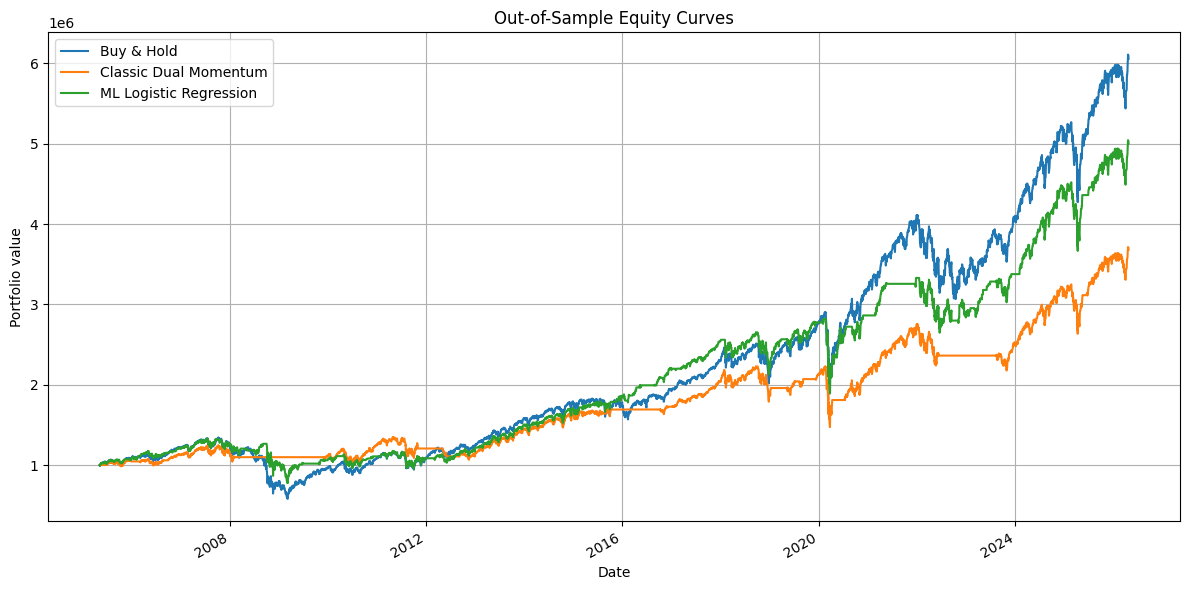

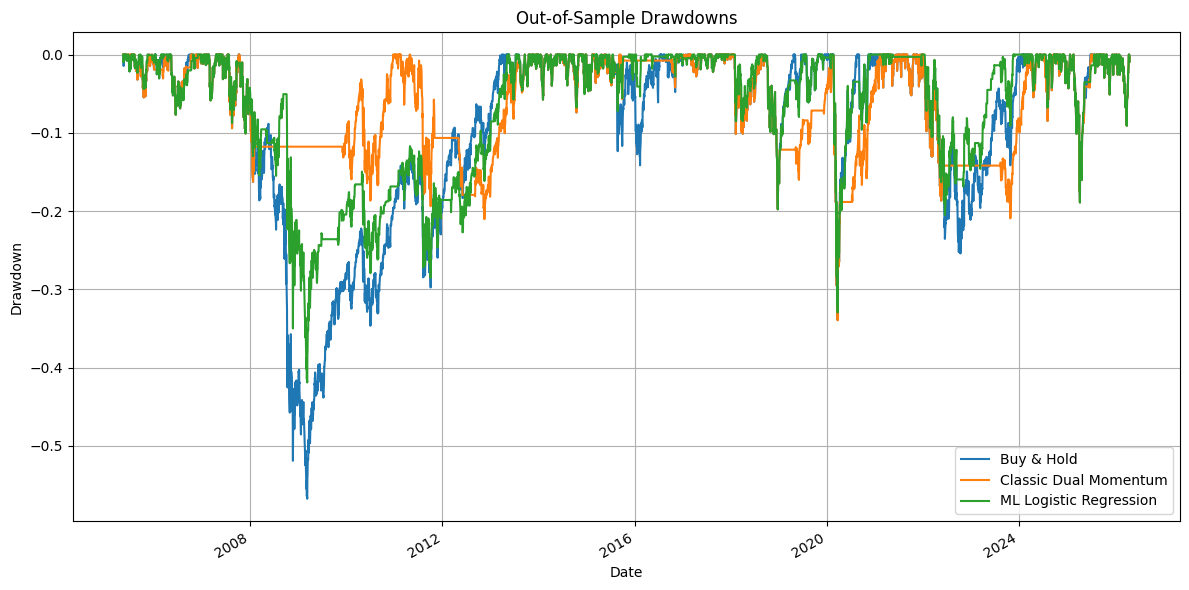

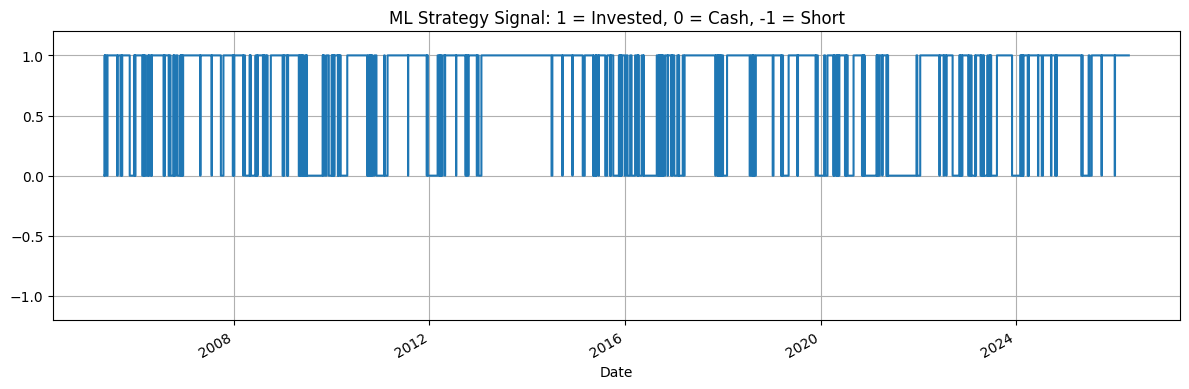

In [13]:
plot_df = pd.DataFrame(index=oos.index)
plot_df["Buy & Hold"] = buy_hold_equity / buy_hold_equity.iloc[0] * cfg.initial_capital
plot_df["Classic Dual Momentum"] = classic_oos["classic_equity"] / classic_oos["classic_equity"].iloc[0] * cfg.initial_capital
plot_df["ML Logistic Regression"] = oos["ml_equity"] / oos["ml_equity"].iloc[0] * cfg.initial_capital

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(ax=ax)
ax.set_title("Out-of-Sample Equity Curves")
ax.set_ylabel("Portfolio value")
fig.tight_layout()
fig.savefig(FIG_DIR / "equity_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
dd_df = plot_df.apply(drawdown)
dd_df.plot(ax=ax)
ax.set_title("Out-of-Sample Drawdowns")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(FIG_DIR / "drawdowns.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
oos["ml_signal"].plot(ax=ax, drawstyle="steps-post")
ax.set_title("ML Strategy Signal: 1 = Invested, 0 = Cash, -1 = Short")
ax.set_ylim(-1.2, 1.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "ml_signal.png", dpi=150)
plt.show()

## 12. Rolling Risk and Return Diagnostics

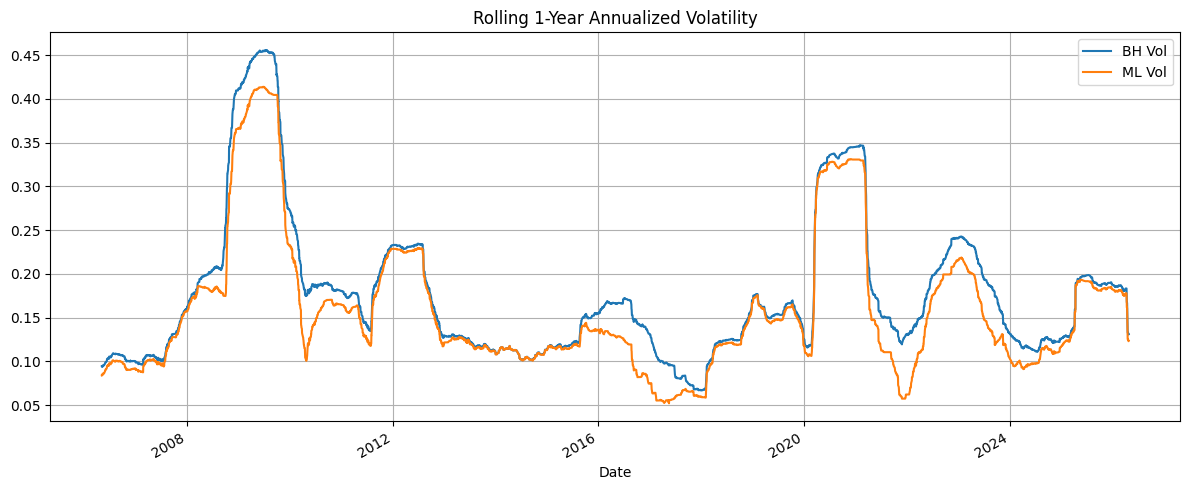

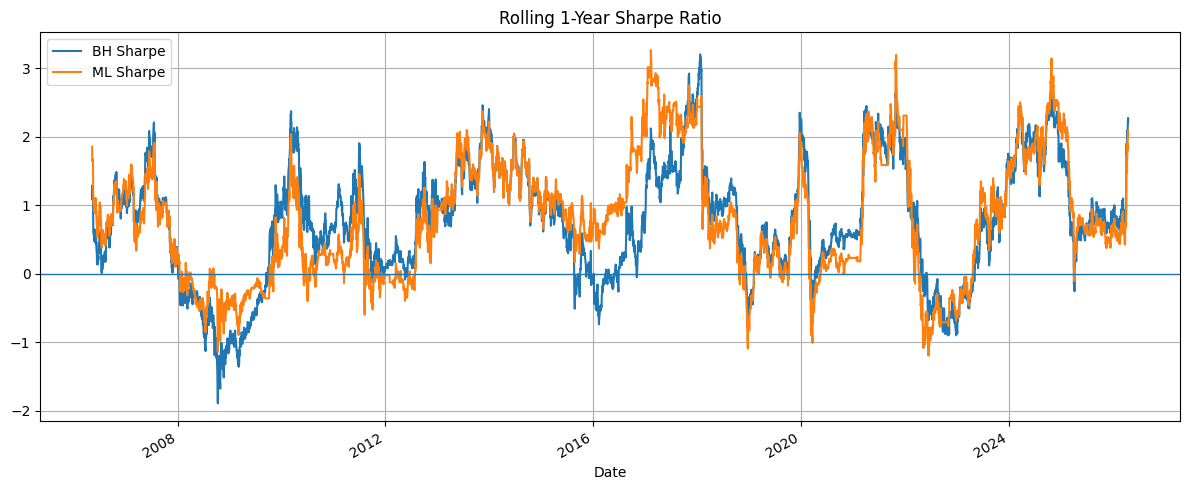

In [14]:
def rolling_annualized_vol(returns: pd.Series, window: int = 252) -> pd.Series:
    return returns.rolling(window).std() * np.sqrt(252)


def rolling_sharpe(returns: pd.Series, window: int = 252, rf_rate: float = 0.01) -> pd.Series:
    ann_ret = returns.rolling(window).mean() * 252
    ann_vol = returns.rolling(window).std() * np.sqrt(252)
    return (ann_ret - rf_rate) / ann_vol

rolling = pd.DataFrame(index=oos.index)
rolling["BH Vol"] = rolling_annualized_vol(buy_hold_ret)
rolling["ML Vol"] = rolling_annualized_vol(oos["ml_ret"])
rolling["BH Sharpe"] = rolling_sharpe(buy_hold_ret, rf_rate=cfg.rf_rate)
rolling["ML Sharpe"] = rolling_sharpe(oos["ml_ret"], rf_rate=cfg.rf_rate)

fig, ax = plt.subplots(figsize=(12, 5))
rolling[["BH Vol", "ML Vol"]].plot(ax=ax)
ax.set_title("Rolling 1-Year Annualized Volatility")
fig.tight_layout()
fig.savefig(FIG_DIR / "rolling_volatility.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
rolling[["BH Sharpe", "ML Sharpe"]].plot(ax=ax)
ax.axhline(0, linewidth=1)
ax.set_title("Rolling 1-Year Sharpe Ratio")
fig.tight_layout()
fig.savefig(FIG_DIR / "rolling_sharpe.png", dpi=150)
plt.show()

## 13. Error Metrics by Walk-Forward Test Set

In [15]:
display_cols = ["Set", "Train Start", "Train End", "Test Start", "Test End", "Train Precision", "Train Recall", "Train F1", "Test Precision", "Test Recall", "Test F1", "Test Accuracy"]
ml_error_metrics[display_cols]

,Set,Train Start,Train End,Test Start,Test End,Train Precision,Train Recall,Train F1,Test Precision,Test Recall,Test F1,Test Accuracy
0,1,1991-06-05,2005-05-09,2005-05-10,2008-05-09,0.600916,0.766048,0.673507,0.578231,0.807601,0.673935,0.564815
1,2,1994-06-01,2008-05-09,2008-05-12,2011-05-10,0.608765,0.795005,0.689531,0.526807,0.551220,0.538737,0.488095
2,3,1997-05-28,2011-05-10,2011-05-11,2014-05-13,0.597310,0.759487,0.668706,0.559701,0.886525,0.686185,0.546296
3,4,2000-05-25,2014-05-13,2014-05-14,2017-05-12,0.593393,0.776000,0.672521,0.597077,0.677725,0.634850,0.564815
4,5,2003-06-03,2017-05-12,2017-05-15,2020-05-14,0.594038,0.864669,0.704249,0.574290,0.781818,0.662175,0.535714
5,6,2006-06-02,2020-05-14,2020-05-15,2023-05-16,0.595551,0.897866,0.716109,0.580381,0.501176,0.537879,0.515873
6,7,2009-06-04,2023-05-16,2023-05-17,2026-04-21,0.598798,0.897898,0.718462,0.574431,0.764569,0.656000,0.531335


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

# Use out-of-sample predictions only
roc_data = oos[["target", "ml_prob", "test_set"]].dropna().copy()
roc_data["target"] = roc_data["target"].astype(int)
roc_data["test_set"] = roc_data["test_set"].astype(int)

# Overall ROC / AUC
fpr, tpr, _ = roc_curve(roc_data["target"], roc_data["ml_prob"])
overall_auc = roc_auc_score(roc_data["target"], roc_data["ml_prob"])
print(f"Overall OOS ROC-AUC: {overall_auc:.4f}")

# AUC by walk-forward test set
auc_by_set = (
    roc_data.groupby("test_set")
    .apply(lambda g: roc_auc_score(g["target"], g["ml_prob"]))
    .rename("Test AUC")
    .to_frame()
)

# Optional: attach AUC to existing metrics table
ml_error_metrics_with_auc = ml_error_metrics.merge(
    auc_by_set.reset_index().rename(columns={"test_set": "Set"}),
    on="Set",
    how="left",
)
display(ml_error_metrics_with_auc[display_cols + ["Test AUC"]])



Overall OOS ROC-AUC: 0.5059


,Set,Train Start,Train End,Test Start,Test End,Train Precision,Train Recall,Train F1,Test Precision,Test Recall,Test F1,Test Accuracy,Test AUC
0,1,1991-06-05,2005-05-09,2005-05-10,2008-05-09,0.600916,0.766048,0.673507,0.578231,0.807601,0.673935,0.564815,0.566037
1,2,1994-06-01,2008-05-09,2008-05-12,2011-05-10,0.608765,0.795005,0.689531,0.526807,0.551220,0.538737,0.488095,0.473453
2,3,1997-05-28,2011-05-10,2011-05-11,2014-05-13,0.597310,0.759487,0.668706,0.559701,0.886525,0.686185,0.546296,0.521720
3,4,2000-05-25,2014-05-13,2014-05-14,2017-05-12,0.593393,0.776000,0.672521,0.597077,0.677725,0.634850,0.564815,0.571856
4,5,2003-06-03,2017-05-12,2017-05-15,2020-05-14,0.594038,0.864669,0.704249,0.574290,0.781818,0.662175,0.535714,0.468872
5,6,2006-06-02,2020-05-14,2020-05-15,2023-05-16,0.595551,0.897866,0.716109,0.580381,0.501176,0.537879,0.515873,0.498418
6,7,2009-06-04,2023-05-16,2023-05-17,2026-04-21,0.598798,0.897898,0.718462,0.574431,0.764569,0.656000,0.531335,0.463044


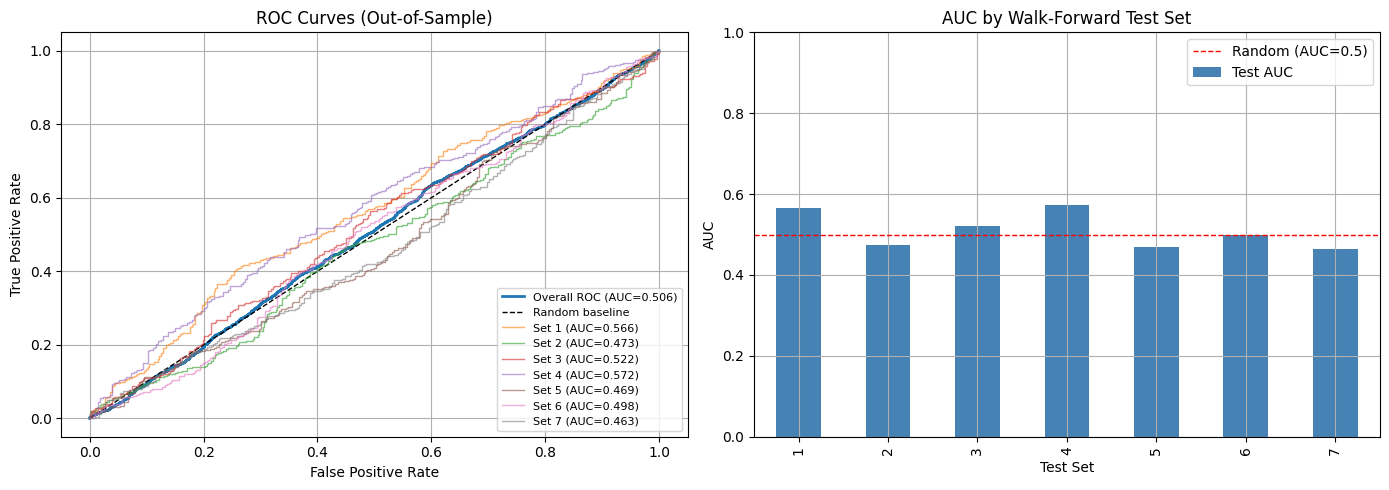

In [26]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Overall ROC + per-set ROC curves
axes[0].plot(fpr, tpr, lw=2, label=f"Overall ROC (AUC={overall_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")

for s in sorted(roc_data["test_set"].unique()):
    g = roc_data[roc_data["test_set"] == s]
    fpr_s, tpr_s, _ = roc_curve(g["target"], g["ml_prob"])
    auc_s = roc_auc_score(g["target"], g["ml_prob"])
    axes[0].plot(fpr_s, tpr_s, lw=1, alpha=0.6, label=f"Set {s} (AUC={auc_s:.3f})")

axes[0].set_title("ROC Curves (Out-of-Sample)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8, loc="lower right")

# (2) AUC by test set
auc_by_set["Test AUC"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random (AUC=0.5)")
axes[1].set_title("AUC by Walk-Forward Test Set")
axes[1].set_xlabel("Test Set")
axes[1].set_ylabel("AUC")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "roc_auc_oos.png", dpi=150)
plt.show()

## 14. Feature Importance Approximation

In [17]:
def get_last_model_feature_importance(model: Pipeline, feature_cols: List[str]) -> pd.DataFrame:
    poly = model.named_steps["poly"]
    logit = model.named_steps["logit"]
    names = poly.get_feature_names_out(feature_cols)
    coefs = logit.coef_.ravel()
    imp = pd.DataFrame({"feature": names, "coef": coefs, "abs_coef": np.abs(coefs)})
    return imp.sort_values("abs_coef", ascending=False)

importance = get_last_model_feature_importance(models[-1], feature_cols)
importance.head(20)

,feature,coef,abs_coef
276,mom_90 mom_360 dd_60,0.829361,0.829361
319,mom_120 mom_360^2,0.784742,0.784742
328,mom_120 dd_60^2,-0.764156,0.764156
289,mom_120^3,-0.759811,0.759811
55,mom_180 mom_270,0.742464,0.742464
278,mom_90 mom_360 dd_120,0.736353,0.736353
348,mom_180 mom_270 dd_120,0.726252,0.726252
6,mom_300,-0.710308,0.710308
345,mom_180 mom_270 dd_15,0.669558,0.669558
399,mom_300^2 mom_360,-0.632788,0.632788


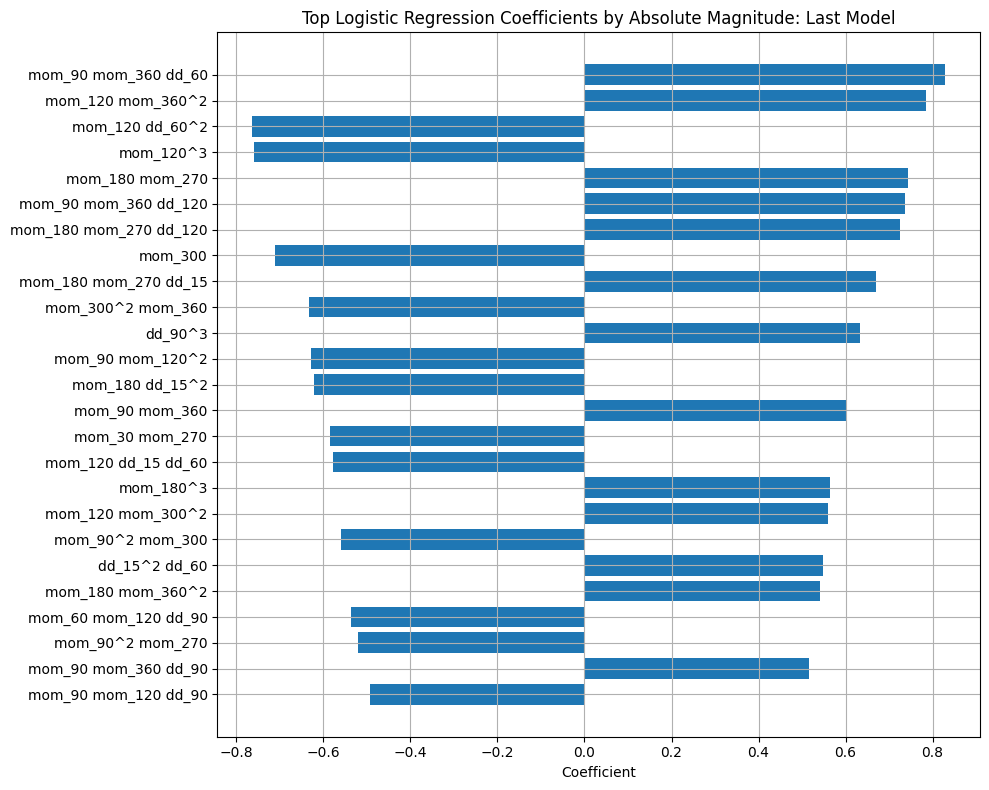

In [18]:
top = importance.head(25).sort_values("abs_coef")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top["feature"], top["coef"])
ax.set_title("Top Logistic Regression Coefficients by Absolute Magnitude: Last Model")
ax.set_xlabel("Coefficient")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_feature_coefficients_last_model.png", dpi=150)
plt.show()

importance.to_csv(TABLE_DIR / "last_model_feature_coefficients.csv", index=False)

## 15. Prediction Horizon and Polynomial-Degree Sensitivity

In [19]:
def run_sensitivity(base_cfg: StrategyConfig, horizons=(1, 2, 3, 5, 10, 15, 21), degrees=(1, 2, 3)) -> pd.DataFrame:
    rows = []
    for h in horizons:
        for deg in degrees:
            tmp_cfg = StrategyConfig(**{**base_cfg.__dict__, "horizon": h, "polynomial_degree": deg})
            tmp_df, tmp_features = make_modeling_frame(prices, tmp_cfg)
            tmp_bt, _, _ = walk_forward_logistic_backtest(tmp_df, tmp_features, tmp_cfg)
            tmp_oos = tmp_bt.dropna(subset=["ml_pred"]).copy()
            eq = tmp_oos["ml_equity"] / tmp_oos["ml_equity"].iloc[0] * tmp_cfg.initial_capital
            rows.append(performance_summary(tmp_oos["ml_ret"], eq, f"H={h}, Degree={deg}", tmp_cfg) | {"Horizon": h, "Degree": deg})
            print(f"Completed horizon={h}, degree={deg}")
    return pd.DataFrame(rows)

# This can take a few minutes. Set RUN_SENSITIVITY = True to execute.
RUN_SENSITIVITY = False

if RUN_SENSITIVITY:
    sensitivity = run_sensitivity(cfg)
    sensitivity.to_csv(TABLE_DIR / "horizon_degree_sensitivity.csv", index=False)
    display(sensitivity)
else:
    print("Sensitivity study skipped. Set RUN_SENSITIVITY=True to run.")

Sensitivity study skipped. Set RUN_SENSITIVITY=True to run.


## 16. Optional: Fixed Retraining Frequency Sensitivity

In [20]:
def run_retraining_sensitivity(base_cfg: StrategyConfig, intervals=(252, 504, 756, 1008, 1260, 1512, 1764, 2016)) -> pd.DataFrame:
    rows = []
    for interval in intervals:
        tmp_cfg = StrategyConfig(**{**base_cfg.__dict__, "retrain_interval": interval})
        tmp_df, tmp_features = make_modeling_frame(prices, tmp_cfg)
        tmp_bt, _, _ = walk_forward_logistic_backtest(tmp_df, tmp_features, tmp_cfg)
        tmp_oos = tmp_bt.dropna(subset=["ml_pred"]).copy()
        eq = tmp_oos["ml_equity"] / tmp_oos["ml_equity"].iloc[0] * tmp_cfg.initial_capital
        rows.append(performance_summary(tmp_oos["ml_ret"], eq, f"Retrain={interval}", tmp_cfg) | {"Retrain Interval": interval})
        print(f"Completed interval={interval}")
    return pd.DataFrame(rows)

RUN_RETRAINING_SENSITIVITY = False

if RUN_RETRAINING_SENSITIVITY:
    retrain_sens = run_retraining_sensitivity(cfg)
    retrain_sens.to_csv(TABLE_DIR / "retraining_sensitivity.csv", index=False)
    display(retrain_sens)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(retrain_sens["Retrain Interval"], retrain_sens["Annual Return"], marker="o", label="Annual Return")
    ax.plot(retrain_sens["Retrain Interval"], retrain_sens["Volatility"], marker="o", label="Volatility")
    ax.set_title("Retraining Frequency Sensitivity")
    ax.set_xlabel("Retraining interval, trading days")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "retraining_sensitivity.png", dpi=150)
    plt.show()
else:
    print("Retraining sensitivity skipped. Set RUN_RETRAINING_SENSITIVITY=True to run.")

Retraining sensitivity skipped. Set RUN_RETRAINING_SENSITIVITY=True to run.


## 17. Long-Short Version

In [21]:
# Run a long-short version without changing the main config.
ls_cfg = StrategyConfig(**{**cfg.__dict__, "long_short": True})
ls_df, ls_features = make_modeling_frame(prices, ls_cfg)
ls_bt, ls_metrics, _ = walk_forward_logistic_backtest(ls_df, ls_features, ls_cfg)
ls_oos = ls_bt.dropna(subset=["ml_pred"]).copy()
ls_equity = ls_oos["ml_equity"] / ls_oos["ml_equity"].iloc[0] * ls_cfg.initial_capital

long_short_summary = pd.DataFrame([
    performance_summary(oos["ml_ret"], oos["ml_equity"] / oos["ml_equity"].iloc[0] * cfg.initial_capital, "ML Long/Cash", cfg),
    performance_summary(ls_oos["ml_ret"], ls_equity, "ML Long/Short", ls_cfg),
])
long_short_summary

,Strategy,Annual Return,Sharpe Ratio,Sortino Ratio,Volatility,Max Drawdown,Average Daily Drawdown,Final Equity
0,ML Long/Cash,0.080004,0.471563,0.584028,0.174290,-0.419077,-0.066346,5.000470e+06
1,ML Long/Short,0.063251,0.363486,0.460400,0.191962,-0.448841,-0.132314,3.606014e+06


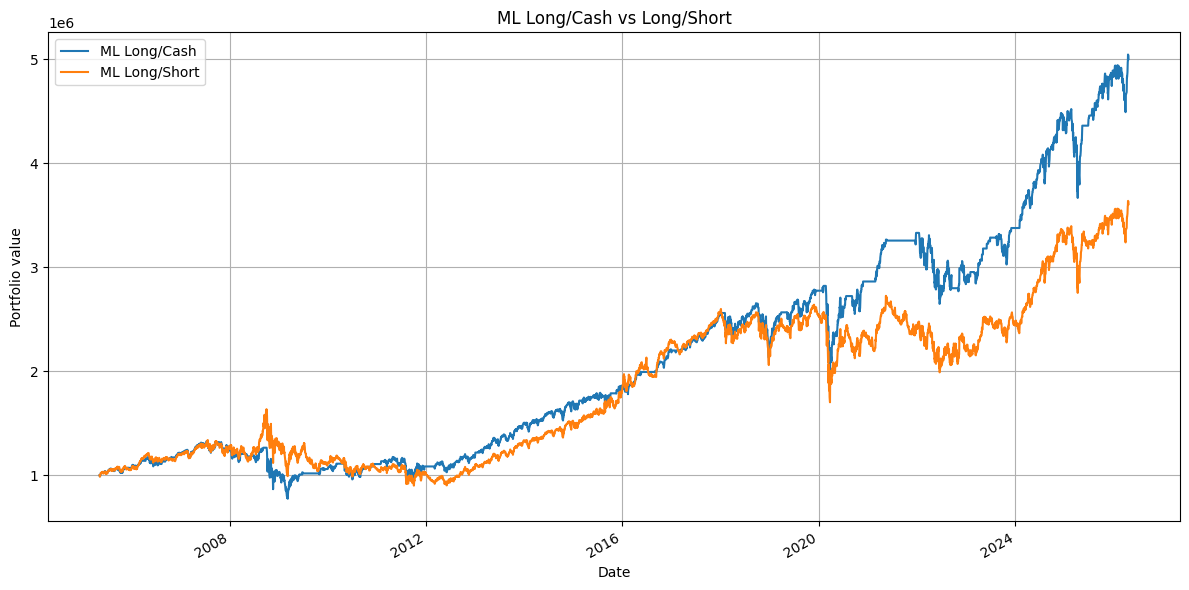

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
(oos["ml_equity"] / oos["ml_equity"].iloc[0] * cfg.initial_capital).plot(ax=ax, label="ML Long/Cash")
ls_equity.plot(ax=ax, label="ML Long/Short")
ax.set_title("ML Long/Cash vs Long/Short")
ax.set_ylabel("Portfolio value")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "long_cash_vs_long_short.png", dpi=150)
plt.show()

## 18. Export Backtest Results

In [23]:
export = oos[["price", "asset_ret", "future_ann_return", "target", "ml_prob", "ml_pred", "ml_signal", "ml_ret", "ml_equity", "test_set"]].copy()
export["buy_hold_equity"] = buy_hold_equity
export["classic_signal"] = classic_oos["classic_signal"]
export["classic_ret"] = classic_oos["classic_ret"]
export["classic_equity"] = classic_oos["classic_equity"] / classic_oos["classic_equity"].iloc[0] * cfg.initial_capital

xlsx_path = RESULTS_DIR / "ml_momentum_backtest_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    export.to_excel(writer, sheet_name="daily_backtest")
    summary.to_excel(writer, sheet_name="performance_summary", index=False)
    ml_error_metrics.to_excel(writer, sheet_name="classification_metrics", index=False)
    importance.head(100).to_excel(writer, sheet_name="top_coefficients", index=False)
    long_short_summary.to_excel(writer, sheet_name="long_short_compare", index=False)

print(f"Saved Excel workbook to: {xlsx_path}")
print(f"Figures saved to: {FIG_DIR}")

Saved Excel workbook to: results\ml_momentum_backtest_results.xlsx
Figures saved to: results\figures


## 19. Interpretation Template

After running the notebook, write your findings in this structure:

1. **Classification performance**: compare train/test precision, recall, and F1. Similar values suggest less evidence of overfitting.
2. **Strategy performance**: compare annual return, Sharpe ratio, volatility, maximum drawdown, and average daily drawdown against buy-and-hold and classic dual momentum.
3. **Risk-control effect**: check whether outperformance comes from avoiding major drawdowns rather than from predicting every daily return correctly.
4. **Model stability**: review coefficient rankings by walk-forward set. Large variation suggests the model is adapting to different regimes.
5. **Sensitivity**: run the horizon/degree and retraining-interval sensitivity cells to see whether the default configuration is robust.
6. **Implementation realism**: subtract realistic costs and slippage before drawing any live-trading conclusion.